Saving Credit_Score.csv to Credit_Score.csv
Dataset:


,Age,Annual_Income,Num_Loans,Outstanding_Debt,Credit_History_Years,Payment_Score,Credit_Score
0,30,141064,5,19613,8,6,Good
1,39,135384,5,6458,18,8,Good
2,21,101736,2,46601,3,10,Good
3,59,71301,5,52133,9,3,Standard
4,51,101465,2,79259,5,1,Poor



Credit Score Accuracy: 0.92

Confusion Matrix:
[[66  0  0]
 [ 0 10  3]
 [ 4  1 16]]


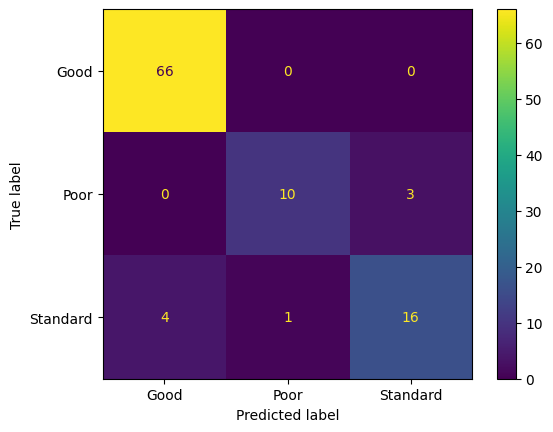

In [1]:
# EXPERIMENT 11: CREDIT SCORE CLASSIFICATION

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Upload CSV
uploaded = files.upload()

# Read CSV
filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset:")
display(df.head())

# Features and target
X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]

# Encode target
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nCredit Score Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()
plt.show()